# **EVALUACIÓN 1**

Mendoza Tordoya, Alessandra Isabel  -  20245523


### **1. Carga y revisión de los datos**

En esta primera parte se cargan las librerías y se establecen los enlaces a los dos archivos utilizados. El archivo ***worldMaps.gpkg*** contiene la información espacial de los países, mientras que ***some_dataworld.csv*** contiene los datos estadísticos que posteriormente se incorporarán al mapa.



In [192]:
import geopandas as gpd
import pandas as pd
linkGitSession='https://github.com/Alessandra-mt/ICDE_-Ev1/raw/main/'

# Archivo espacial
linkGPKG= linkGitSession + 'worldMaps.gpkg'
# Archivo con los datos estadísticos
linkCSV= linkGitSession + 'some_dataworld.csv'

**Revisión del archivo espacial**

Primero se revisan las capas disponibles dentro del GeoPackage para identificar la capa que contiene los países.

In [193]:
# Se revisan las capas disponibles en el GeoPackage
gpd.list_layers(linkGPKG)

,name,geometry_type
0,rivers,MultiLineString
1,cities,Point
2,countries,MultiPolygon


Se utiliza específicamente la capa *countries*, ya que es la geometría que se necesita para representar los países.

In [194]:
# Se carga la capa espacial de países
countries=gpd.read_file(linkGPKG, layer='countries')
countries.head()

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."


Se revisan las características principales del GeoDataFrame.




In [195]:
# Dimensiones del GeoDataFrame
countries.shape
# Nombres de las columnas
countries.columns
# Información general y tipos de datos
countries.info()
# Tipo de geometría
countries.geom_type.unique()
# Sistema de coordenadas
countries.crs

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   COUNTRY   252 non-null    object  
 1   geometry  252 non-null    geometry
dtypes: geometry(1), object(1)
memory usage: 4.1+ KB


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich


**Revisión de los datos estadísticos**

En esta parte se carga el archivo CSV como un DataFrame. Se revisa su contenido y estructura antes de realizar modificaciones.

In [196]:
# Se lee el archivo CSV
someData=pd.read_csv(linkCSV)
someData.head()

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000


Se revisan las dimensiones, columnas, tipos de datos y posibles valores faltantes.

In [197]:
# Dimensiones del DataFrame
someData.shape
# Nombres de las columnas
someData.columns
# Información general y tipos de datos
someData.info()
# Se revisan los valores faltantes
someData.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       172 non-null    object 
 1   iso2          171 non-null    object 
 2   iso3          172 non-null    object 
 3   region        172 non-null    object 
 4   fragility     172 non-null    float64
 5   co2           172 non-null    int64  
 6   sq_km         172 non-null    int64  
 7   num_airports  172 non-null    int64  
 8   population    172 non-null    int64  
 9   mobiles       172 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 13.6+ KB


,0
Country,0
iso2,1
iso3,0
region,0
fragility,0
co2,0
sq_km,0
num_airports,0
population,0
mobiles,0


### **2. Preparación de los datos para el Geo Merge**
Para integrar la información espacial con los datos estadísticos se necesita una columna común que permita relacionar ambas fuentes. En este caso, la clave será *Country*.



**Normalización de la clave**

En el GeoDataFrame la columna aparece como COUNTRY, mientras que en el DataFrame estadístico aparece como Country. Primero se iguala el nombre y luego se convierten los nombres de los países a mayúsculas.

In [198]:
# Se iguala el nombre de la columna clave
countries.rename(columns={'COUNTRY':'Country'}, inplace=True)
# Se normalizan los nombres de los países
countries['Country']=countries.Country.str.upper()
countries.head()

,Country,geometry
0,ARUBA (NETHERLANDS),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,ANTIGUA AND BARBUDA,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,AFGHANISTAN,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,ALGERIA,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,AZERBAIJAN,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."


**Revisión de diferencias entre los nombres**

Se identifican los países que aparecen solamente en cada fuente. Esto permite detectar nombres que podrían impedir una coincidencia durante la unión.

In [199]:
# Países que aparecen en el CSV pero no en el GeoDataFrame
onlyDF=set(someData.Country)-set(countries.Country)
# Países que aparecen en el GeoDataFrame pero no en el CSV
onlyGDF=set(countries.Country)-set(someData.Country)

print("Solo en someData:",len(onlyDF))
print("Solo en countries:",len(onlyGDF))

Solo en someData: 30
Solo en countries: 110


### **3. Corrección de nombres de países**

Cuando los nombres no coinciden exactamente, se utiliza *thefuzz* para encontrar posibles coincidencias entre ambas fuentes.

In [200]:
# Se instala la librería para comparar nombres
!pip install thefuzz

# Se importa la función para encontrar la coincidencia más cercana
from thefuzz.process import extractOne as best

Se muestran las coincidencias encontradas junto con su nivel de similitud para poder revisar los nombres antes de realizar los reemplazos.

In [201]:
# Revisamos las coincidencias entre los nombres diferentes
pd.DataFrame([(Country,best(Country,onlyGDF)[0],best(Country,onlyGDF)[1]) for Country in onlyDF]).sort_values(by=2)

,0,1,2
24,CÔTE D'IVOIRE,IVORY COAST,58
28,ESWATINI,MARTINIQUE (FRANCE),60
17,CABO VERDE,CAPE VERDE,80
19,TIMOR-LESTE,EAST TIMOR,81
2,LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE),CZECH REPUBLIC,86
4,KOREA (THE REPUBLIC OF),CZECH REPUBLIC,86
6,NORTH MACEDONIA,MACEDONIA,90
0,SAMOA,AMERICAN SAMOA (US),90
13,NIGER (THE),NIGER,90
11,BOLIVIA (PLURINATIONAL STATE OF),BOLIVIA,90


Se establecen las equivalencias necesarias para los nombres que no coinciden entre ambas fuentes.

In [202]:
# Se crea el diccionario con las coincidencias revisadas
changesToDF = {country:best(country,onlyGDF)[0] for country in onlyDF}
changesToDF

{'SAMOA': 'AMERICAN SAMOA (US)',
 'CENTRAL AFRICAN REPUBLIC (THE)': 'CENTRAL AFRICAN REPUBLIC',
 "LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)": 'CZECH REPUBLIC',
 'NETHERLANDS (THE)': 'NETHERLANDS',
 'KOREA (THE REPUBLIC OF)': 'CZECH REPUBLIC',
 'PHILIPPINES (THE)': 'PHILIPPINES',
 'NORTH MACEDONIA': 'MACEDONIA',
 'CONGO (THE)': 'CONGO',
 'RUSSIAN FEDERATION (THE)': 'RUSSIA',
 'BRUNEI DARUSSALAM': 'BRUNEI',
 'SUDAN (THE)': 'SUDAN',
 'BOLIVIA (PLURINATIONAL STATE OF)': 'BOLIVIA',
 'NORTHERN MARIANA ISLANDS (THE)': 'NORTHERN MARIANA ISLANDS (US)',
 'NIGER (THE)': 'NIGER',
 'DOMINICAN REPUBLIC (THE)': 'DOMINICAN REPUBLIC',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)': 'DEMOCRATIC REPUBLIC OF THE CONGO',
 'TANZANIA, THE UNITED REPUBLIC OF': 'TANZANIA',
 'CABO VERDE': 'CAPE VERDE',
 'IRAN (ISLAMIC REPUBLIC OF)': 'IRAN',
 'TIMOR-LESTE': 'EAST TIMOR',
 'COMOROS (THE)': 'COMOROS',
 'GAMBIA (THE)': 'GAMBIA',
 'MICRONESIA (FEDERATED STATES OF)': 'FEDERATED STATES OF MICRONESIA',
 'BAHAMAS (THE)': 'BAHAM

Se aplican las correcciones al DataFrame estadístico.

In [230]:
# Se reemplazan los nombres para que coincidan con el GeoDataFrame
someData.replace(to_replace={'Country':changesToDF},inplace=True)

Finalmente, se vuelve a comprobar la correspondencia entre ambas fuentes.

In [231]:
# Se comprueban nuevamente las diferencias
onlyDF=set(someData.Country)-set(countries.Country)
onlyGDF=set(countries.Country)-set(someData.Country)

print("Solo en someData:",len(onlyDF))
print("Solo en countries:",len(onlyGDF))

Solo en someData: 0
Solo en countries: 81


### **4. Integración de la información espacial y estadística**

Una vez que la columna *Country* presenta nombres compatibles, se realiza la unión de ambas fuentes. El resultado conserva la geometría de los países y añade las variables estadísticas.

In [232]:
# Se une la información espacial con los datos estadísticos
theMapAndData=countries.merge(someData,on='Country')
theMapAndData.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Country       172 non-null    object  
 1   geometry      172 non-null    geometry
 2   iso2          171 non-null    object  
 3   iso3          172 non-null    object  
 4   region        172 non-null    object  
 5   fragility     172 non-null    float64 
 6   co2           172 non-null    int64   
 7   sq_km         172 non-null    int64   
 8   num_airports  172 non-null    int64   
 9   population    172 non-null    int64   
 10  mobiles       172 non-null    int64   
dtypes: float64(1), geometry(1), int64(5), object(4)
memory usage: 14.9+ KB


Se guarda el GeoDatoFrame en un archivo.

In [206]:
theMapAndData.to_file("indicadoresMundiales.json")

### **5. Selección del área de estudio**

El análisis se concentra en los países pertenecientes a América del Norte, América del Sur, América Central y el Caribe. Estas categorías se encuentran identificadas en la variable *region*.

In [234]:
# Se seleccionan los países correspondientes a América
America=theMapAndData[theMapAndData.region.isin(['SOUTH AMERICA','CENTRAL AMERICA AND THE CARIBBEAN','NORTH AMERICA'])]
America.head()

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,ANTIGUA AND BARBUDA,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ...",AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
8,ARGENTINA,"MULTIPOLYGON (((-71.01648 -36.47591, -70.98195...",AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000
12,BARBADOS,"MULTIPOLYGON (((-59.53306 13.05055, -59.54542 ...",BB,BRB,CENTRAL AMERICA AND THE CARIBBEAN,48.0,1703000,430,1,304139,323000
15,BAHAMAS,"MULTIPOLYGON (((-77.95029 26.89778, -77.91695 ...",BS,BHS,CENTRAL AMERICA AND THE CARIBBEAN,48.8,3984000,13880,54,410862,400000
17,BELIZE,"MULTIPOLYGON (((-88.28914 17.1225, -88.28001 1...",BZ,BLZ,CENTRAL AMERICA AND THE CARIBBEAN,62.5,541000,22966,27,415789,264000


### **6. Revisión y transformación del sistema de coordenadas**

Antes de generar los mapas temáticos se revisa el sistema de coordenadas utilizado por los datos.

In [236]:
# Se revisa el CRS
America.crs
# Se comprueba si el CRS está proyectado
America.crs.is_projected

False

Como el sistema original no está proyectado, se realiza una transformación a **EPSG 8858**, permitiendo trabajar con una representación proyectada de América.

<Axes: >

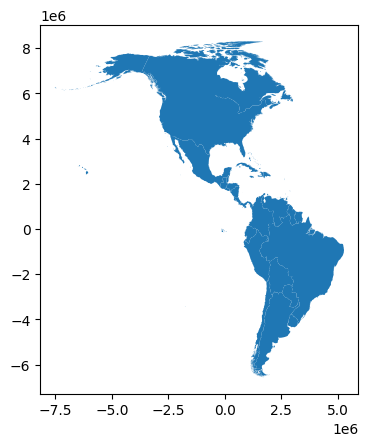

In [237]:
# Se reproyecta América
America_proj=America.to_crs(8858)
# Se comprueba visualmente la proyección
America_proj.plot()

### **7. DDM — Dot Density Map**

El Dot Density Map representa cantidades mediante puntos distribuidos dentro de las áreas. En este caso, cada punto representa una cantidad determinada de usuarios de teléfonos móviles.

Primero se establece el valor que representa cada punto y se calcula cuántos puntos corresponden a cada país.

In [238]:
# Se crea una copia para trabajar con el DDM
justDots=America_proj.copy()
# Cada punto representa 100 000 usuarios de teléfonos móviles
dot_value=100000
# Se calcula la cantidad de puntos que tendrá cada país
justDots['num_dots']=(justDots['mobiles']/dot_value).astype(int)

Los puntos se generan dentro de las geometrías de los países.

In [239]:
# Se generan los puntos dentro de cada país
justDots=justDots.sample_points(size=justDots['num_dots']).explode(index_parts=True)
# Se reinicia el índice
justDots.reset_index(drop=True,inplace=True)

Se crea un nuevo GeoDataFrame que contiene las geometrías de los puntos.

In [240]:
# Se crea el GeoDataFrame de puntos
America_dots=gpd.GeoDataFrame(geometry=justDots)
# Se muestran los puntos generados
America_dots

,geometry
0,POINT (2642551.7 2241591.171)
1,POINT (1629908.901 -6061841.237)
2,POINT (2253768.412 -4826365.259)
3,POINT (1668130.753 -5169606.506)
4,POINT (2145822.705 -4337933.791)
...,...
11503,POINT (2581302.931 1161360.937)
11504,POINT (2463371.63 824090.113)
11505,POINT (2067608.196 886864.541)
11506,POINT (2336815.264 1032450.001)


Finalmente, los puntos se superponen sobre el mapa de América.

<Axes: >

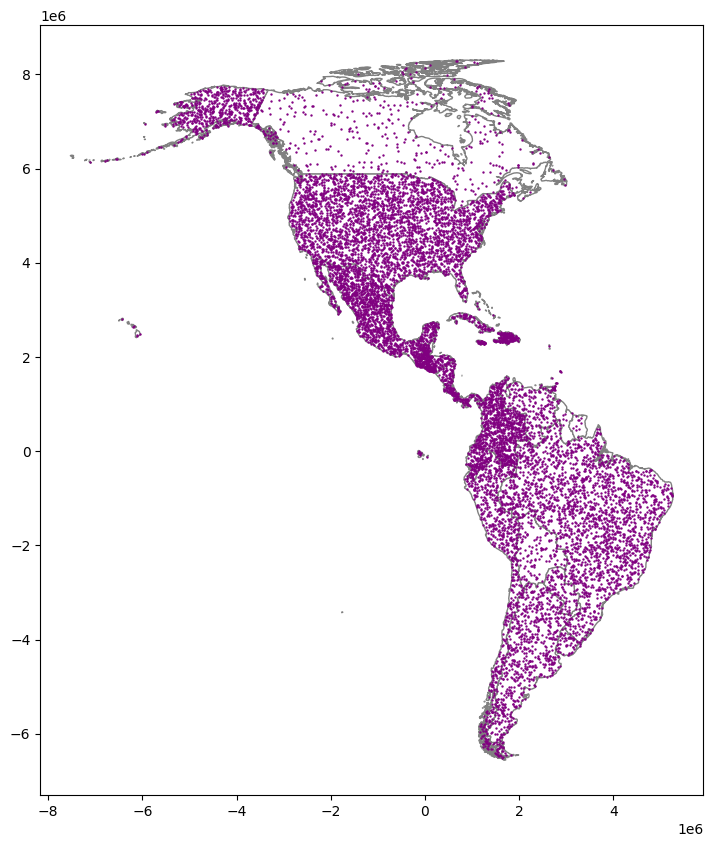

In [243]:
# Se crea el mapa base
base=America_proj.plot(facecolor='white',edgecolor='grey',figsize=(10,10))
# Se agrega los puntos del DDM
America_dots.plot(markersize=0.5,color='purple',ax=base)


### **8. PSM — Proportional Symbol Map**

El Proportional Symbol Map representa la magnitud de *mobiles* mediante símbolos cuyo tamaño aumenta de acuerdo con la cantidad de usuarios.

Para ubicar los símbolos se utiliza un punto representativo dentro de cada país. Esto permite trabajar adecuadamente con geometrías complejas o multipolígonos.

In [214]:
# Se crea una copia para el PSM
America_centroids=America_proj.copy()
# Se obtiene un punto representativo dentro de cada país
America_centroids['geometry']=America_proj.representative_point()
# Se calcula el tamaño inicial de los símbolos
America_centroids['size']=America_centroids['mobiles'].apply(lambda x:x**0.5/100)

Se revisan posibles valores atípicos en la cantidad de usuarios de teléfonos móviles.

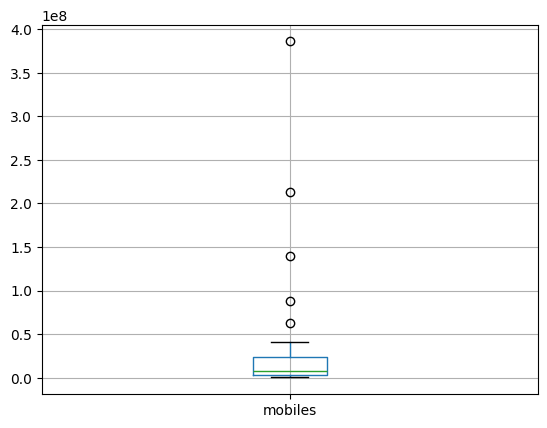

In [215]:
# Se identifican posibles valores atípicos
boxplotInfo=America_centroids.boxplot(column='mobiles',return_type='dict')

In [216]:
# Se extraen los valores identificados como outliers
outliers=boxplotInfo['fliers'][0].get_ydata()
outliers

array([62700000, 213000000, 87400000, 140000000, 386000000], dtype=object)

Se identifican los países correspondientes a dichos valores.

In [244]:
# Se revisan los países con valores atípicos
America_centroids[America_centroids.mobiles.isin(outliers)]

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,size,mobiles_outliers
8,ARGENTINA,POINT (2265962.186 -4493827.822),AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,79.183332,1
23,BRAZIL,POINT (3803192.426 -1764170.762),BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,145.945195,1
38,COLOMBIA,POINT (1675341.523 525486.665),CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,93.487967,1
110,MEXICO,POINT (-1120447.446 2972427.316),MX,MEX,NORTH AMERICA,69.7,463739000,1964375,1580,130739927,140000000,118.321596,1
159,UNITED STATES,POINT (-768981.361 4547618.41),US,USA,NORTH AMERICA,38.0,5144361000,9833517,16116,341963408,386000000,196.468827,1


Se agrega una variable que identifica los registros con valores atípicos.

In [218]:
# Se identifica los outliers con 1 y los demás con 0
America_centroids['mobiles_outliers']=(America_centroids.mobiles.isin(outliers)*1)
# Se verifica el GeoDataFrame actualizado
America_centroids

,Country,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,size,mobiles_outliers
0,ANTIGUA AND BARBUDA,POINT (2646987.996 2176408.939),AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000,4.289522,0
8,ARGENTINA,POINT (2265962.186 -4493827.822),AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,79.183332,1
12,BARBADOS,POINT (2878303.996 1688332.479),BB,BRB,CENTRAL AMERICA AND THE CARIBBEAN,48.0,1703000,430,1,304139,323000,5.683309,0
15,BAHAMAS,POINT (1545442.282 2682348.628),BS,BHS,CENTRAL AMERICA AND THE CARIBBEAN,48.8,3984000,13880,54,410862,400000,6.324555,0
17,BELIZE,POINT (119868.834 2194756.836),BZ,BLZ,CENTRAL AMERICA AND THE CARIBBEAN,62.5,541000,22966,27,415789,264000,5.138093,0
19,BOLIVIA,POINT (2392919.118 -2073238.575),BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,34.641016,0
23,BRAZIL,POINT (3803192.426 -1764170.762),BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,145.945195,1
28,CANADA,POINT (-1229013.274 6460418.072),CA,CAN,NORTH AMERICA,20.0,612084000,9984670,1459,38794813,36500000,60.415230,0
35,CHILE,POINT (1655151.382 -4304799.911),CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,51.672043,0
38,COLOMBIA,POINT (1675341.523 525486.665),CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,93.487967,1


Se separan los registros con y sin valores atípicos para controlar su representación visual.

In [219]:
# Separación los países con y sin valores atípicos
America_centroids_out=America_centroids[America_centroids.mobiles_outliers==1].copy()
America_centroids_no_out=America_centroids[America_centroids.mobiles_outliers==0].copy()

Se ajusta el tamaño de los símbolos para la representación final.

In [220]:
# Se calcula el tamaño final de los símbolos
America_centroids_out['size']=America_centroids_out['mobiles'].apply(lambda x:x**0.5/50)
America_centroids_no_out['size']=America_centroids_no_out['mobiles'].apply(lambda x:x**0.5/50)

Finalmente, se representan los símbolos sobre el mapa base.

<Axes: >

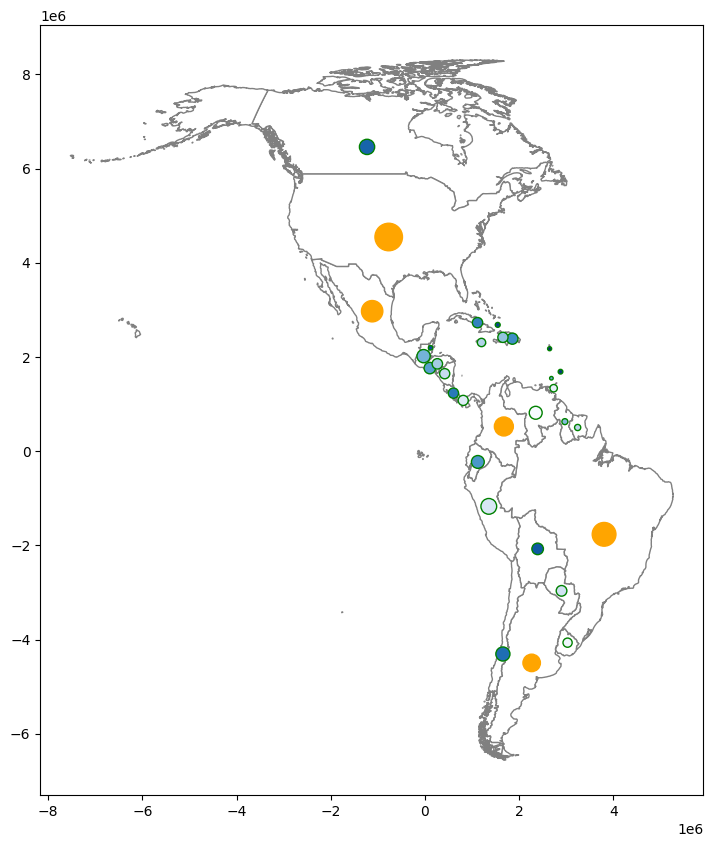

In [221]:
# Se crea el mapa base
base=America_proj.plot(facecolor='white',edgecolor='grey',figsize=(10,10))
# Se representa los países sin valores atípicos
America_centroids_no_out.plot(
    ax=base,
    markersize=America_centroids_no_out['size'],
    edgecolor='green',
    c=America_centroids_no_out['size'],
    cmap='Blues_r')
# Se representa los países con valores atípicos
America_centroids_out.plot(
    ax=base,
    markersize=America_centroids_out['size'],
    color='orange')


### **9. Choropleth**

En un Choropleth se colorea la superficie de cada país. Para evitar que el tamaño del territorio influya directamente en la representación de una cantidad absoluta, se utiliza una variable normalizada.

En este caso se calcula la cantidad de usuarios de teléfonos móviles por cada 100 habitantes.



In [222]:
# Se calcula los usuarios de móviles por cada 100 habitantes
America_proj['mobiles_population_100']=(America_proj['mobiles']/America_proj['population']*100)
# Se revisa la distribución de la variable
America_proj['mobiles_population_100'].describe()

,mobiles_population_100
count,31.000000
mean,115.160634
std,32.580830
min,60.159411
25%,97.075904
50%,108.133237
75%,140.713797
max,179.277822


**Clasificación de la variable**

Para representar el indicador mediante categorías se prueban diferentes métodos de clasificación. Posteriormente se comparan mediante el valor de ADCM

In [223]:
# Se importan las librerías para la clasificación
import mapclassify
import numpy as np
# Se fija una semilla para obtener resultados reproducibles
np.random.seed(12345)
# Número de clases
K=5

# Variable que será clasificada
theVar=America_proj['mobiles_population_100']

Se aplican diferentes métodos de clasificación.

In [224]:
# Se clasifica por intervalos iguales
ei5=mapclassify.EqualInterval(theVar,k=K)
# Se clasifica según desviaciones estándar
msd = mapclassify.StdMean(theVar)
# Se clasifica por cuantiles
q5=mapclassify.Quantiles(theVar,k=K)
# Se clasifica por máximos quiebres
mb5 = mapclassify.MaximumBreaks(theVar)
# Se clasifica por Head quiebres cabeza-cola
ht = mapclassify.HeadTailBreaks(theVar)
# Se clasifica por Fisher-Jenks
fj5=mapclassify.FisherJenks(theVar,k=K)
# Se clasifica por Jenks-Caspall
jc5=mapclassify.JenksCaspall(theVar,k=K)
# Se clasifica por Max-P
mp5 = mapclassify.MaxP(theVar, k=K)

Se comparan los valores de ADCM de los métodos utilizados.

<Axes: ylabel='Classifier'>

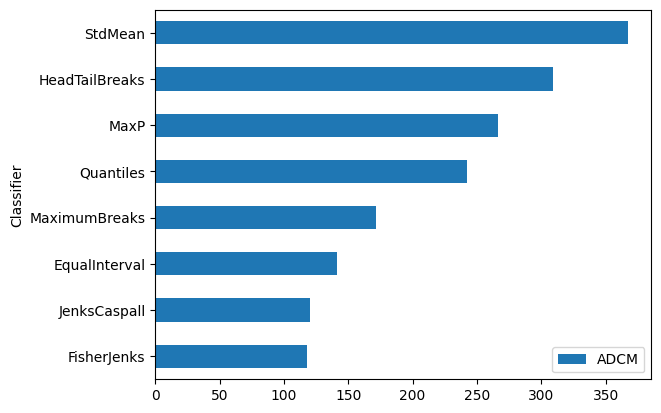

In [225]:
# Se resume a los clasificadores
class5=ei5,msd, q5,mb5,  ht, fj5, jc5, mp5
# Se obtiene el ADCM de cada método
fits=np.array([c.adcm for c in class5])
# Se crea una tabla comparativa
adcms=pd.DataFrame(fits)
# Se agrega el nombre de cada clasificador
adcms['classifier']=[c.name for c in class5]
adcms.columns=['ADCM','Classifier']
# Se ordenan los métodos por su ADCM
adcms.sort_values('ADCM').plot.barh(x='Classifier')

Para la representación final se utiliza la clasificación Fisher-Jenks con cinco categorías.

In [226]:
# Se guardan las clases obtenidas mediante Fisher-Jenks
America_proj['mobiles_population_100_fj5']=fj5.yb

Se crean etiquetas para facilitar la lectura de las categorías.

In [227]:
# Creación de etiquetas para las cinco categorías
newLabelsForLevels={
    0:'0_MuyBajo',
    1:'1_Bajo',
    2:'2_Medio',
    3:'3_Alto',
    4:'4_MuyAlto'
}
America_proj['mobiles_population_100_fj5_cat']=(America_proj['mobiles_population_100_fj5'].replace(newLabelsForLevels))
# Se verifica las clases asignadas
America_proj[['mobiles_population_100','mobiles_population_100_fj5','mobiles_population_100_fj5_cat']].head(20)

,mobiles_population_100,mobiles_population_100_fj5,mobiles_population_100_fj5_cat
0,179.277822,4,4_MuyAlto
8,133.420198,3,3_Alto
12,106.201441,2,2_Medio
15,97.356290,1,1_Bajo
17,63.493743,0,0_MuyBajo
19,97.466093,1,1_Bajo
23,96.795518,1,1_Bajo
28,94.084743,1,1_Bajo
35,143.051154,3,3_Alto
38,176.251050,4,4_MuyAlto


Finalmente, se genera el mapa coroplético.

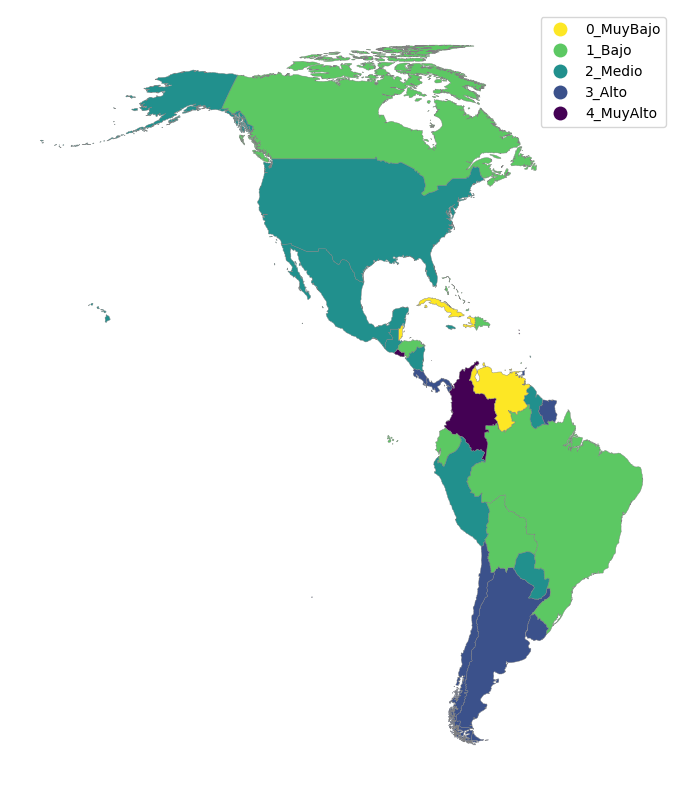

In [228]:
# Se importa las librerias
import matplotlib.pyplot as plt
# Se crea el mapa coroplético
f,ax=plt.subplots(1,figsize=(10,10))

America_proj.plot(
    column='mobiles_population_100_fj5_cat',
    cmap='viridis_r',
    categorical=True,
    edgecolor='grey',
    linewidth=0.3,
    legend=True,
    ax=ax
)
# Ocultamos los ejes
ax.set_axis_off()

### **10. Guardado de los resultados**

En esta última parte se almacenan los resultados en un mismo GeoPackage. Cada representación se guarda como una capa independiente para facilitar su posterior utilización.

In [229]:
# Se guardan los resultados en un mismo GeoPackage
America_proj.to_file('america_mobiles.gpkg',driver='GPKG',layer='continent')
America_dots.to_file('america_mobiles.gpkg',driver='GPKG',layer='mobiles_ddm')
America_centroids.to_file('america_mobiles.gpkg',driver='GPKG',layer='mobiles_psm')
America_centroids_out.to_file('america_mobiles.gpkg',driver='GPKG',layer='outlier_mobiles_psm')
America_centroids_no_out.to_file('america_mobiles.gpkg',driver='GPKG',layer='no_outlier_mobiles_psm')